### 102.M. Binary Tree Level Order Traversal

Given the root of a binary tree, return the level order traversal of its nodes' values. (i.e., from left to right, level by level).

Example: 

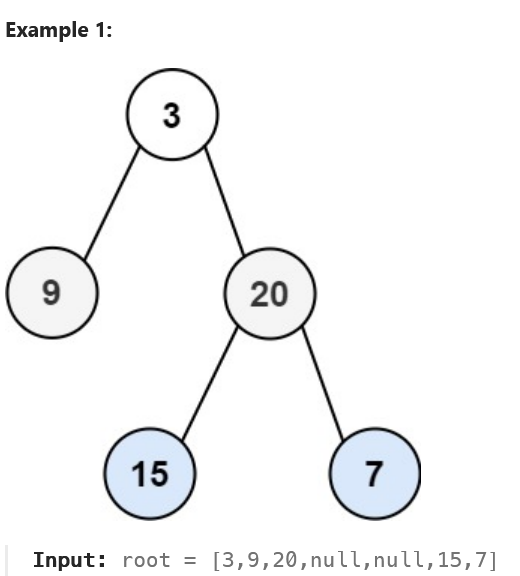

Input: [3, 9, 20, null, null, 15, 7]

Output: [[3], [9, 20], [15, 7]]

Constraints:
    1. Any limit n max number of nodes 
    2. Node values are integers ? and range ? 
    


In [ ]:
from collections import deque

class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val 
        self.left = left
        self.right = right

class Solution:
    def levelOrder(self, root: Optional[TreeNode]) -> List[List[int]]:
        # Check if the queue is empty
        if not root:
            return []

        # initialize the final output
        result = []
        # creates a queue (FIFO) and starts with the root node inside it
        # a deque is selected because of efficient popping from the left 
        queue = deque([root])

        # loop through as long as there are nodes to process in the queue
        while queue:
            # temporary list to stores the nodes at a particular level
            level = []
            print (len(queue))

            for _ in range(len(queue)):
                node = queue.popleft()
                level.append(node.val)
                if node.left:
                    queue.append(node.left)
                if node.right:
                    queue.append(node.right)
            result.append(level)
        return result


Key Observations
At Step 1, the queue only has the root. We process it, then add its children.

At Step 2, the queue has exactly the nodes of level 1 (2 and 3). We process them, then add their children.

At Step 3, the queue has exactly the nodes of level 2 (4, 5, 6). We process them, no children left.

At Step 4, the queue is empty, so traversal ends.

## Solving using a hashmap 

In [ ]:
# deque: a double-ended queue, efficient for popping from the left (FIFO).
# defaultdict(list): a dictionary that automatically creates an empty list for new keys.

from typing import Optional, List
from collections import deque, defaultdict

class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val 
        self.left = left
        self.right = right

class Solution:
    def levelOrder(self, root: Optional[TreeNode]) -> List[List[int]]:
        if not root:
            return []
        # Creates a hashmap where each key is a level number (0, 1, 2, …).
        #Each value is a list of node values at that level.
        levels = defaultdict(list)
        # Initializes the BFS queue with a tuple (root, 0).
        # The tuple stores both the node and its level number.
        queue = deque([(root, 0)])

        while queue:
            # Retrieves both the node and its level.
            node, level = queue.popleft()
            # Adds the node’s value to the list corresponding to its level in the hashmap.
            levels[level].append(node.val)

            if node.left:
                # If the node has a left child, enqueue it with level + 1.
                queue.append((node.left, level+1))
            if node.right:
                queue.append((node.right, level+1))             
            
        # Collect results in order of levels 
        return [levels[i] for i in range(len(levels))]
    
   
    def dfs(self, root: Optional[TreeNode]) -> List[List[int]]:
        levels = defaultdict(list)

        def helper(node, level):
            if not node:
                return
            levels[level].append(node.val)
            helper(node.left, level + 1)
            helper(node.right, level + 1)

        helper(root, 0)
        return [levels[i] for i in range(len(levels))]


    

sol = Solution()        
# 1. Empty tree
root_empty = None
print("Empty tree:", sol.levelOrder(root_empty))  
print("DFS Empty tree:", sol.dfs(root_empty))
# Expected: []

# 2. Single-node tree
root_single = TreeNode(42)
print("Single-node tree:", sol.levelOrder(root_single))  
print("Single-node tree:", sol.dfs(root_single)) 

# Expected: [[42]]

# 3. Multi-level tree
#         1
#        / \
#       2   3
#      / \   \
#     4   5   6
root = TreeNode(1)
root.left = TreeNode(2, TreeNode(4), TreeNode(5))
root.right = TreeNode(3, None, TreeNode(6))
print("Multi-level tree:", sol.levelOrder(root))  
print("Multi-level tree (DFS):", sol.dfs(root))  
# Expected: [[1], [2, 3], [4, 5, 6]]




Empty tree: []
DFS Empty tree: []
Single-node tree: [[42]]
Single-node tree: [[42]]
Multi-level tree: [[1], [2, 3], [4, 5, 6]]
Multi-level tree (DFS): [[1], [2, 3], [4, 5, 6]]


Multi-level tree: [[1], [3, 2], [4, 5, 6]]


{0: [1], 1: [2, 3]}
{0: [1], 1: [3, 2]}
